# Stage 07 — Outliers and Risk Assumptions

Stage 07. **I based it on the lecture notebook.**

In [1]:
# Install missing packages (uncomment and run to install).
# !pip install numpy pandas matplotlib scikit-learn

In [2]:
from pathlib import Path

# Project root.
ROOT = Path.cwd()
if not (ROOT/"src/outliers.py").exists() and (ROOT.parent/"src/outliers.py").exists():
    ROOT = ROOT.parent

CHECKS = [
    ("src/outliers.py", "NEEDED", "IQR, Z-score, and winsorize helpers"),
]

print(f"Looking in: {ROOT}\n")
missing = 0
for rel, kind, note in CHECKS:
    here = (ROOT/rel).exists()
    if not here and kind == "NEEDED":
        missing += 1
    print(f"  [{'OK ' if here else 'MISS'}]  {kind:<8}  {rel:<34}  {note}")

if missing:
    raise FileNotFoundError(f"{missing} needed file(s) missing under {ROOT}")
print("\nAll needed files present.")

Looking in: /Users/ghostof0days/projects/bootcamp/homework/homework07

  [OK ]  NEEDED    src/outliers.py                     IQR, Z-score, and winsorize helpers

All needed files present.


In [3]:
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Import helpers from src/.
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.outliers import detect_outliers_iqr, detect_outliers_zscore, winsorize_series

RAW = ROOT/"data/raw"
PROC = ROOT/"data/processed"
RAW.mkdir(parents=True, exist_ok=True)
PROC.mkdir(parents=True, exist_ok=True)

## Generate raw dataset

In [4]:
# seeded randomness.
np.random.seed(17)

csv_path = RAW/"outliers_homework.csv"
if csv_path.exists():
    print("File already exists at", csv_path)
else:
    dates = pd.date_range(start="2022-01-03", end="2022-06-10", freq="B")
    returns = np.random.normal(0, 0.01, size=len(dates))
    # nudge the pre-may mean down a little.
    returns[dates < pd.Timestamp("2022-05-01")] -= 0.0015
    shock_values = {
        # these values are from stage 7 starter code
        "2022-05-02": 0.1748425237194541,
        "2022-05-03": -0.16825801732486943,
        "2022-05-06": -0.19667220757153227,
        "2022-05-09": 0.21240223590614747,
        "2022-05-12": -0.178729287231294,
    }
    for shock_date, shock_return in shock_values.items():
        idx = np.where(dates == pd.to_datetime(shock_date))[0][0]
        returns[idx] = shock_return
    # correlated second column plus a little noise.
    daily_return_2 = returns * 0.6 + np.random.normal(0, 0.005, size=len(dates))
    sample = pd.DataFrame({
        "date": dates,
        "daily_return": returns,
        "daily_return_2": daily_return_2,
    })
    sample.to_csv(csv_path, index=False)
    print("Saved raw CSV:", csv_path)

File already exists at /Users/ghostof0days/projects/bootcamp/homework/homework07/data/raw/outliers_homework.csv


## Load raw dataset

In [5]:
# load the generated csv.
sample = pd.read_csv(csv_path, parse_dates=["date"])
print("Original shape:", sample.shape)
print("Original NA count:\n", sample.isna().sum())
sample.head()

Original shape: (115, 3)
Original NA count:
 date              0
daily_return      0
daily_return_2    0
dtype: int64


,date,daily_return,daily_return_2
0,2022-01-03,0.001263,0.003834
1,2022-01-04,-0.020046,-0.009506
2,2022-01-05,0.004739,-0.000535
3,2022-01-06,0.009953,0.012539
4,2022-01-07,0.008872,0.009840


## Detect outliers and create flags

In [6]:
# flag outliers on daily_return.
target_column = "daily_return"
sample["outlier_iqr"] = detect_outliers_iqr(sample[target_column], k=1.5)
sample["outlier_zscore"] = detect_outliers_zscore(sample[target_column], threshold=3.0)
iqr_outlier_fraction = sample["outlier_iqr"].mean()
zscore_outlier_fraction = sample["outlier_zscore"].mean()
iqr_outliers = sample.loc[sample["outlier_iqr"], ["date", target_column]]
print("IQR outlier fraction:", iqr_outlier_fraction)
print("Z-score outlier fraction:", zscore_outlier_fraction)
print(iqr_outliers)

IQR outlier fraction: 0.0782608695652174
Z-score outlier fraction: 0.043478260869565216
         date  daily_return
41 2022-03-01      0.031952
63 2022-03-31     -0.031101
85 2022-05-02      0.174843
86 2022-05-03     -0.168258
87 2022-05-04     -0.033999
89 2022-05-06     -0.196672
90 2022-05-09      0.212402
92 2022-05-11      0.028711
93 2022-05-12     -0.178729


## Figures

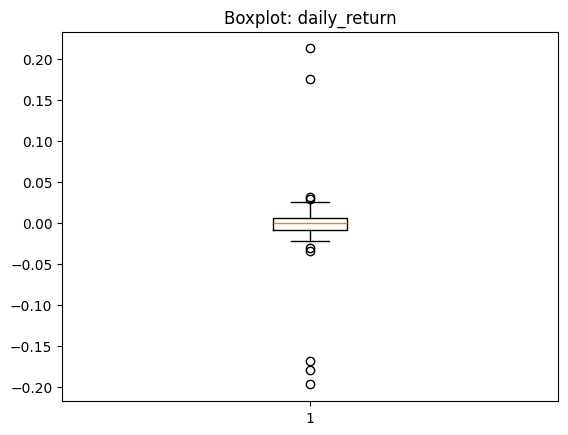

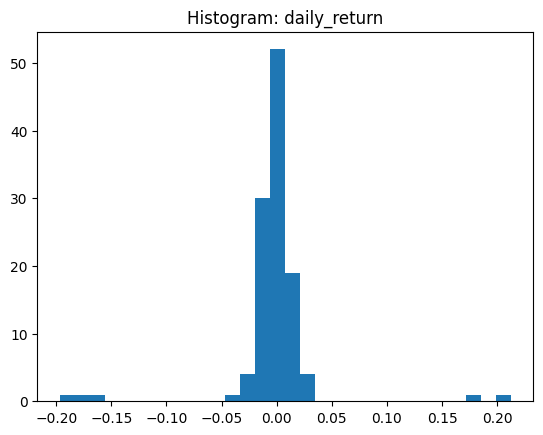

In [7]:
# boxplot and histogram of daily_return.
plt.figure()
plt.boxplot(sample[target_column])
plt.title(f"Boxplot: {target_column}")
plt.show()

plt.figure()
plt.hist(sample[target_column], bins=30)
plt.title(f"Histogram: {target_column}")
plt.show()

## Sensitivity analysis

In [8]:
# ~ flips the iqr mask so we keep non-outlier rows.
summary_all = sample[target_column].describe()[["mean", "50%", "std"]].rename({"50%": "median"})
summary_outliers_dropped = sample.loc[~sample["outlier_iqr"], target_column].describe()[["mean", "50%", "std"]].rename({"50%": "median"})
winsorized = winsorize_series(sample[target_column])
summary_winsorized = winsorized.describe()[["mean", "50%", "std"]].rename({"50%": "median"})
comparison = pd.concat({"all": summary_all, "outliers_dropped": summary_outliers_dropped, "winsorized": summary_winsorized}, axis=1)
print("Summary statistics:")
comparison

Summary statistics:


,all,outliers_dropped,winsorized
mean,-0.001434,-0.000039,-0.000251
median,-0.000187,-0.000100,-0.000187
std,0.040579,0.009443,0.010623


In [9]:
# same regression on all rows, dropped outliers, and winsorized x.
response_column = "daily_return_2"
print("Regressing", response_column, "on", target_column)

rows_without_outliers = ~sample["outlier_iqr"]
features_all = sample[[target_column]].to_numpy()
response_all = sample[response_column].to_numpy()
features_outliers_dropped = sample.loc[rows_without_outliers, [target_column]].to_numpy()
response_outliers_dropped = sample.loc[rows_without_outliers, response_column].to_numpy()
features_winsorized = winsorized.to_numpy().reshape(-1, 1)
response_winsorized = sample[response_column].to_numpy()

model_all = LinearRegression().fit(features_all, response_all)
model_outliers_dropped = LinearRegression().fit(features_outliers_dropped, response_outliers_dropped)
model_winsorized = LinearRegression().fit(features_winsorized, response_winsorized)

results = pd.DataFrame({
    "slope": [model_all.coef_[0], model_outliers_dropped.coef_[0], model_winsorized.coef_[0]],
    "intercept": [model_all.intercept_, model_outliers_dropped.intercept_, model_winsorized.intercept_],
    "r2": [
        model_all.score(features_all, response_all),
        model_outliers_dropped.score(features_outliers_dropped, response_outliers_dropped),
        model_winsorized.score(features_winsorized, response_winsorized),
    ],
    "mae": [
        mean_absolute_error(response_all, model_all.predict(features_all)),
        mean_absolute_error(response_outliers_dropped, model_outliers_dropped.predict(features_outliers_dropped)),
        mean_absolute_error(response_winsorized, model_winsorized.predict(features_winsorized)),
    ],
}, index=["all", "outliers_dropped", "winsorized"])
print("Regression comparison:")
results

Regressing daily_return_2 on daily_return
Regression comparison:


,slope,intercept,r2,mae
all,0.605869,0.000201,0.961859,0.003951
outliers_dropped,0.589679,-0.000049,0.573566,0.003851
winsorized,1.467237,-0.000300,0.386601,0.010746


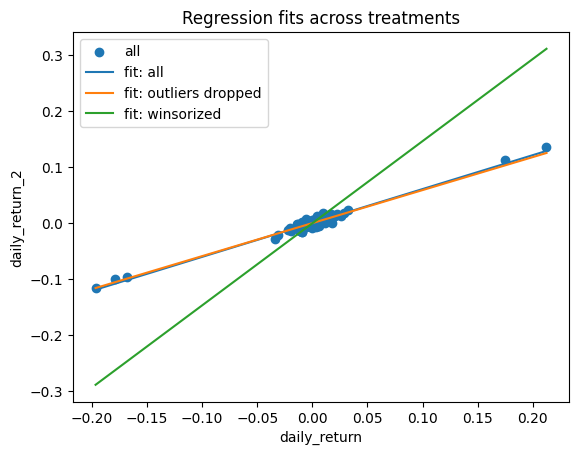

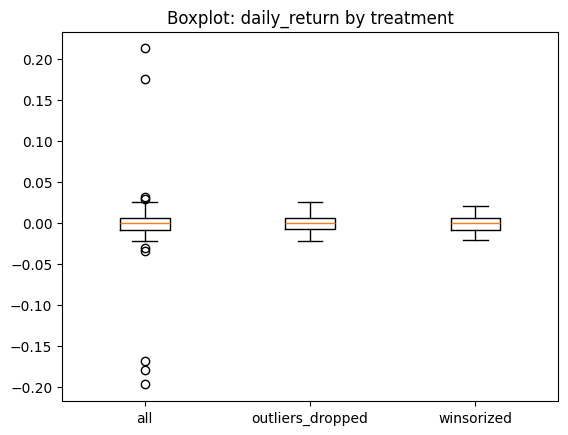

In [10]:
plt.figure()
plt.scatter(sample[target_column], sample[response_column], label="all")
x_line = np.linspace(sample[target_column].min(), sample[target_column].max(), 100)
plt.plot(x_line, model_all.coef_[0] * x_line + model_all.intercept_, label="fit: all")
plt.plot(x_line, model_outliers_dropped.coef_[0] * x_line + model_outliers_dropped.intercept_, label="fit: outliers dropped")
plt.plot(x_line, model_winsorized.coef_[0] * x_line + model_winsorized.intercept_, label="fit: winsorized")
plt.legend()
plt.title("Regression fits across treatments")
plt.xlabel(target_column)
plt.ylabel(response_column)
plt.show()

plt.figure()
plt.boxplot(
    [sample[target_column], sample.loc[rows_without_outliers, target_column], winsorized],
    tick_labels=["all", "outliers_dropped", "winsorized"],
)
plt.title(f"Boxplot: {target_column} by treatment")
plt.show()

In [11]:
# write the regression table.
sensitivity_path = PROC/"outlier_sensitivity.csv"
results.to_csv(sensitivity_path)
print("Saved sensitivity CSV:", sensitivity_path)

Saved sensitivity CSV: /Users/ghostof0days/projects/bootcamp/homework/homework07/data/processed/outlier_sensitivity.csv


## Documentation

- I generated `data/raw/outliers_homework.csv` with the starter seed and May shocks.
- I flagged IQR outliers on `daily_return` with k=1.5.
- I also flagged Z-score outliers with threshold 3.0.
- I winsorized `daily_return` at 5% and 95%.
- I compared mean, median, and std for all, filtered, and winsorized.
- I fit a linear regression of `daily_return_2` on `daily_return` for those three treatments.
- I saved the regression table to `data/processed/outlier_sensitivity.csv`.
- I put the helpers in `src/outliers.py`.

Assumptions and risks:
- When I used IQR with k=1.5,=I assumed quartiles could capture the majority of daily returns.
- When I used Z-score with ddof=0, I assumed a roughly normal sample.
- When I winsorized at 5%/95%, I assumed the tails are noisy.
- If the May shocks are crash days, then dropping them would hide the risk.

## Reflection

I chose IQR with k=1.5 because the starter series contains small daily noise plus a few May shocks. I don't assume normality because the quartiles are near zero, so the shocks are accounted for. I computed Z-score at 3.0, so I could see whether the same days were flagged. For Z-score, I used population standard deviation because of labeling this sample isntead of estimating a population parameter. I also ran winsorize at 5%/95% to keep every row but make a cap for the tails.

My decisions assume the majority of `daily_return` is mostly around zero and that the extreme May values are mostly noise. The data I used also has no missing values, so dealing NA didn't change anything. I made NA flags as False and rejected empty series and non-positive k or threshold to stop bad inputs.

Dropping the IQR outliers reduced the mean and std of `daily_return` a lot since the May shocks were a large part of both. Median changed less as I epxected. I also ran the regression of `daily_return_2` on `daily_return` for all three versions. When I left the shocks in, slope and MAE got moved a lot by the five shock days. Without these datapoints in, the fit is closer to the 0.6 I used to build `daily_return_2`. Winsorize was between the two. I also looked at R^2 since dropping points can make the R^2 go up even when I threw away real dates.

If the May shocks were actually crash days, then me dropping them would make the model look more stable than the market actually is. If I picked k to be too small, I would end up flagging ordinary days. If I trusted Z-score on the sample, the shocks would increase standatrd deviation a lot and I might miss them.